Input Shape for Hybrid Model: (73651, 11, 1)

--- Training CNN Stage ---
Epoch 1/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1537 - mae: 0.2791 - val_loss: 0.1359 - val_mae: 0.2660
Epoch 2/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1337 - mae: 0.2602 - val_loss: 0.1246 - val_mae: 0.2540
Epoch 3/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1269 - mae: 0.2527 - val_loss: 0.1200 - val_mae: 0.2509
Epoch 4/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1209 - mae: 0.2466 - val_loss: 0.1206 - val_mae: 0.2544
Epoch 5/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1171 - mae: 0.2427 - val_loss: 0.1178 - val_mae: 0.2543
Epoch 6/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1122 - mae: 0.2370 - val_loss: 0.1124 - val_mae: 0.2480
Epoch 7/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1088 - mae: 0.2337 - val_loss: 0.1073 - val_mae: 0.2357
Epoch 8/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1059 - mae: 0.2

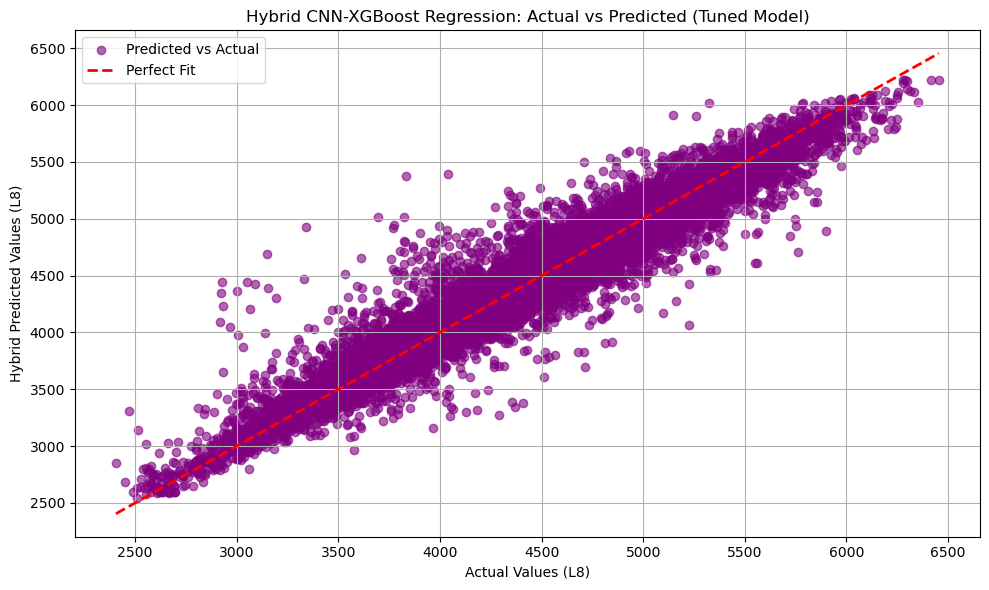

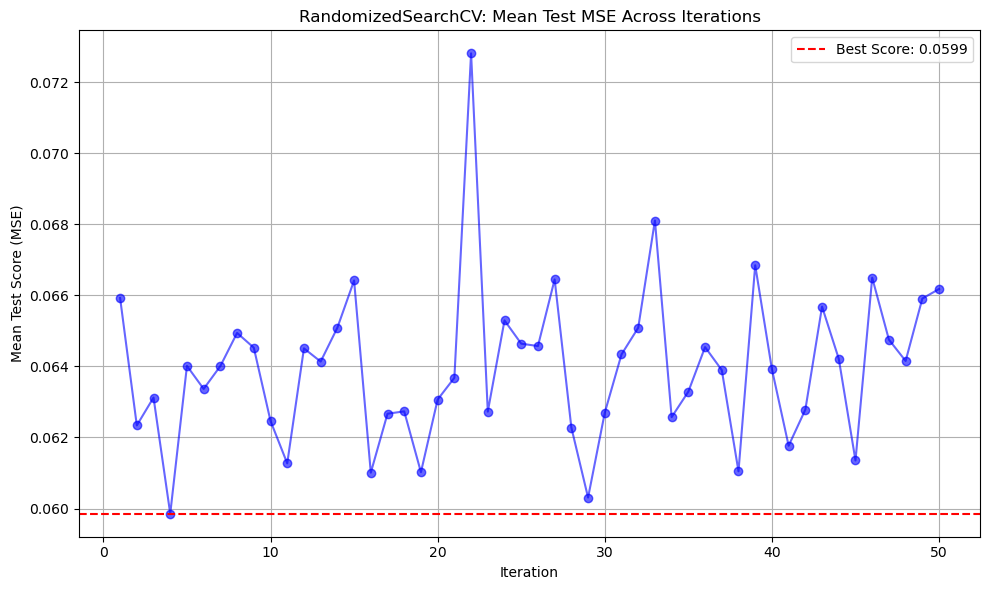

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor
from scipy.stats import uniform, randint

# ===============================
#  ADD MAPE FUNCTION
# ===============================
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    # avoid division by zero
    epsilon = 1e-7
    y_true = np.where(y_true == 0, epsilon, y_true)
    
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
try:
    df = pd.read_excel("Feature_engineering_DS.xlsx")
except FileNotFoundError:
    print("Error: File 'Feature_engineering_DS.xlsx' not found. Please ensure it is in the directory.")
    exit()

X = df.drop(["L8", "date"], axis=1).values
y = df["L8"].values.reshape(-1, 1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
y_train_s = y_scaler.fit_transform(y_train)
X_val_s = x_scaler.transform(X_val)
y_val_s = y_scaler.transform(y_val)
X_test_s = x_scaler.transform(X_test)
y_test_s = y_scaler.transform(y_test)

X_train_cnn = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_val_cnn = X_val_s.reshape(X_val_s.shape[0], X_val_s.shape[1], 1)
X_test_cnn = X_test_s.reshape(X_test_s.shape[0], X_test_s.shape[1], 1)

print(f"Input Shape for Hybrid Model: {X_train_cnn.shape}")

# ==========================================
# 2. TRAIN CNN (Feature Extractor Stage)
# ==========================================
print("\n--- Training CNN Stage ---")

inputs = Input(shape=(X_train_cnn.shape[1], 1))
x = Conv1D(filters=64, kernel_size=2, activation='relu')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(filters=32, kernel_size=2, activation='relu')(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

features = Dense(32, activation='relu', name='feature_layer')(x)
outputs = Dense(1, activation='linear')(features)

cnn_model = Model(inputs=inputs, outputs=outputs)

optimizer = Adam(learning_rate=0.001)
cnn_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn_model.fit(
    X_train_cnn, y_train_s,
    validation_data=(X_val_cnn, y_val_s),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 3. HYBRIDIZATION (Feature Extraction)
# ==========================================
print("\n--- Extracting Features from CNN for XGBoost ---")

feature_extractor = Model(inputs=inputs, outputs=features)

X_train_features = feature_extractor.predict(X_train_cnn)
X_val_features = feature_extractor.predict(X_val_cnn)
X_test_features = feature_extractor.predict(X_test_cnn)

print(f"New Feature Shape for XGBoost: {X_train_features.shape}")

X_train_val_features = np.vstack([X_train_features, X_val_features])
y_train_val_s = np.vstack([y_train_s, y_val_s])

# ==========================================
# 4. HYPERPARAMETER TUNING
# ==========================================
print("\n--- Performing RandomizedSearchCV for XGBoost Hyperparameter Tuning ---")

param_dist = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.29),
    'max_depth': randint(3, 11),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 6),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2)
}

xgb_base = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print("Starting hyperparameter search... This may take a few minutes.")
random_search.fit(X_train_val_features, y_train_val_s.ravel())

xgb_model = random_search.best_estimator_

print("\n--- Best Hyperparameters Found ---")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV Score (Neg MSE): {random_search.best_score_:.4f}")

# ==========================================
# 5. EVALUATION ON TEST SET
# ==========================================
print("\n--- Evaluating Best Model on Test Set ---")

pred_s = xgb_model.predict(X_test_features).reshape(-1, 1)

pred_real = y_scaler.inverse_transform(pred_s)
y_test_real = y_scaler.inverse_transform(y_test_s)

rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
mae = mean_absolute_error(y_test_real, pred_real)
mse = mean_squared_error(y_test_real, pred_real)
r2 = r2_score(y_test_real, pred_real)

# ===============================
#   ADD MAPE HERE
# ===============================
mape = mean_absolute_percentage_error(y_test_real, pred_real)

print("\n--- Hybrid CNN-XGBoost Model Results (After Tuning) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"R2  : {r2:.4f}")
print(f"MAPE: {mape:.4f}%")

# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, pred_real, alpha=0.6, color='purple', label='Predicted vs Actual')
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Values (L8)")
plt.ylabel("Hybrid Predicted Values (L8)")
plt.title("Hybrid CNN-XGBoost Regression: Actual vs Predicted (Tuned Model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

cv_results = pd.DataFrame(random_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cv_results) + 1), -cv_results['mean_test_score'], 'bo-', alpha=0.6)
plt.axhline(y=-random_search.best_score_, color='r', linestyle='--',
            label=f'Best Score: {-random_search.best_score_:.4f}')
plt.xlabel('Iteration')
plt.ylabel('Mean Test Score (MSE)')
plt.title('RandomizedSearchCV: Mean Test MSE Across Iterations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
# ==========================================
# ADD THIS SECTION AT THE END OF YOUR TRAINING SCRIPT
# (After the visualization section)
# ==========================================

import pickle
import joblib

print("\n" + "="*60)
print("SAVING TRAINED MODELS AND SCALERS")
print("="*60)

# Save the CNN feature extractor
feature_extractor.save('cnn_feature_extractor.h5')
print("✓ CNN feature extractor saved to 'cnn_feature_extractor.h5'")

# Save the XGBoost model
joblib.dump(xgb_model, 'xgb_model.pkl')
print("✓ XGBoost model saved to 'xgb_model.pkl'")

# Save the scalers
with open('x_scaler.pkl', 'wb') as f:
    pickle.dump(x_scaler, f)
print("✓ X scaler saved to 'x_scaler.pkl'")

with open('y_scaler.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)
print("✓ Y scaler saved to 'y_scaler.pkl'")

print("\n✓ All models and scalers saved successfully!")
print("\nYou can now use the testing script to make predictions on new data.")
print("="*60)


SAVING TRAINED MODELS AND SCALERS
✓ CNN feature extractor saved to 'cnn_feature_extractor.h5'
✓ XGBoost model saved to 'xgb_model.pkl'
✓ X scaler saved to 'x_scaler.pkl'
✓ Y scaler saved to 'y_scaler.pkl'

✓ All models and scalers saved successfully!

You can now use the testing script to make predictions on new data.


Loading trained models and scalers...
✓ CNN feature extractor loaded successfully
✓ XGBoost model loaded successfully
✓ X scaler loaded successfully
✓ Y scaler loaded successfully

Loading new test data from 2025_testing.xlsx...
✓ Test data loaded successfully: 11520 samples

Test Data Columns: ['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'Weekends', 'holiday', 'local/national', 'Week', 'L8', 'date']
Test Data Shape: (11520, 13)

Preparing test data...
✓ Target variable 'L8' found - will evaluate model performance
Feature shape: (11520, 11)

Scaling and reshaping data...
Scaled shape: (11520, 11, 1)

Extracting features using CNN...
✓ Features extracted: (11520, 32)

Making predictions using XGBoost...
✓ Predictions generated: 11520 samples

Saving predictions...
✓ Predictions saved to '2025_testing_predictions.xlsx'
✓ Predictions also saved to 'predictions_only.csv'

MODEL PERFORMANCE EVALUATION

RMSE (Root Mean Squared Error)     : 429.7588
MAE  (Mean Absolute Error)         : 299.5944

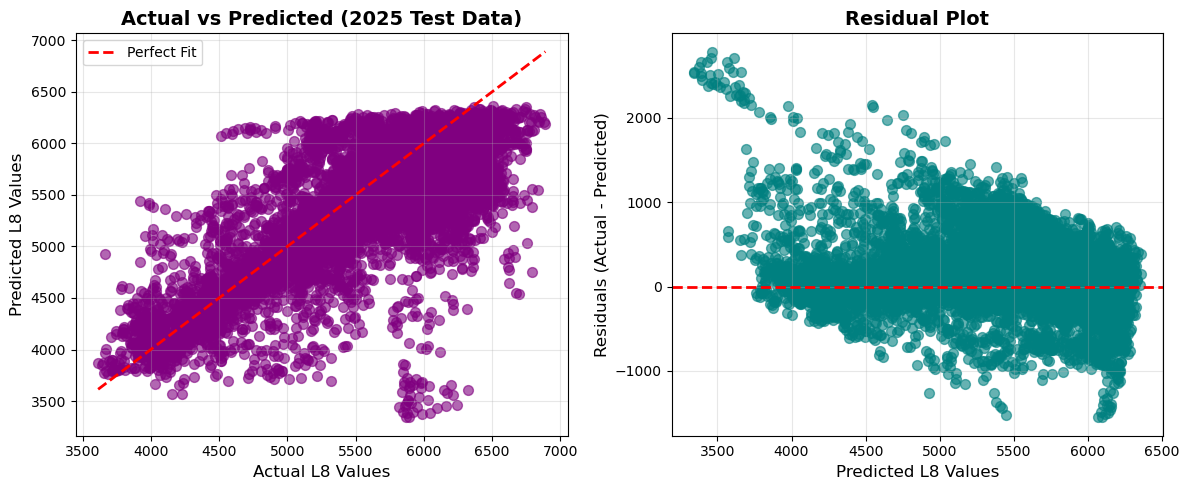

✓ Distribution plot saved to 'distribution_comparison.png'


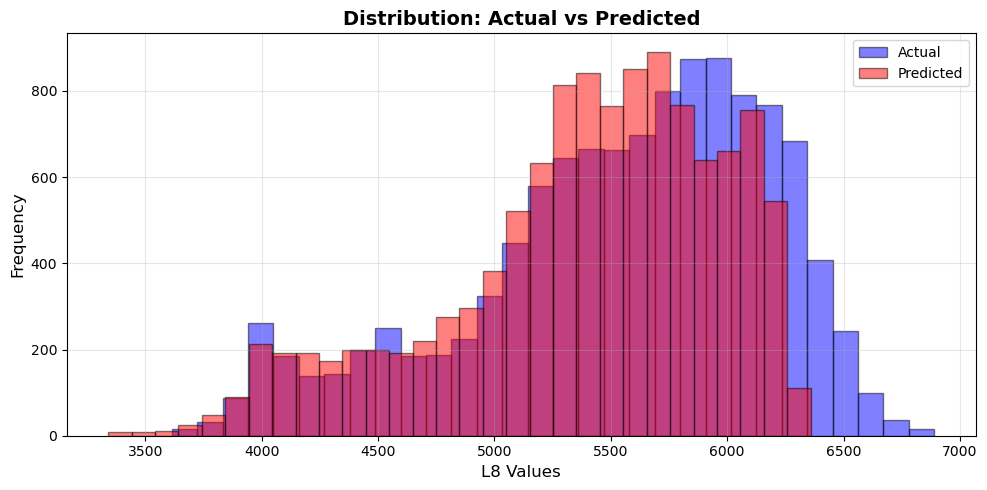


TESTING COMPLETE!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import load_model
import pickle
import joblib

# ==========================================
# 1. LOAD SAVED MODELS AND SCALERS
# ==========================================
print("Loading trained models and scalers...")

try:
    # Load the CNN feature extractor
    feature_extractor = load_model('cnn_feature_extractor.h5')
    print("✓ CNN feature extractor loaded successfully")
    
    # Load the XGBoost model
    xgb_model = joblib.load('xgb_model.pkl')
    print("✓ XGBoost model loaded successfully")
    
    # Load the scalers
    with open('x_scaler.pkl', 'rb') as f:
        x_scaler = pickle.load(f)
    print("✓ X scaler loaded successfully")
    
    with open('y_scaler.pkl', 'rb') as f:
        y_scaler = pickle.load(f)
    print("✓ Y scaler loaded successfully")
    
except FileNotFoundError as e:
    print(f"\nError: {e}")
    print("\nPlease run the training script first and ensure these files are saved:")
    print("  - cnn_feature_extractor.h5")
    print("  - xgb_model.pkl")
    print("  - x_scaler.pkl")
    print("  - y_scaler.pkl")
    exit()

# ==========================================
# 2. LOAD NEW TEST DATA
# ==========================================
print("\nLoading new test data from 2025_testing.xlsx...")

try:
    df_test = pd.read_excel("2025_testing.xlsx")
    print(f"✓ Test data loaded successfully: {df_test.shape[0]} samples")
except FileNotFoundError:
    print("Error: File '2025_testing.xlsx' not found. Please ensure it is in the directory.")
    exit()

# Display basic info about the test data
print(f"\nTest Data Columns: {list(df_test.columns)}")
print(f"Test Data Shape: {df_test.shape}")

# ==========================================
# 3. PREPARE TEST DATA
# ==========================================
print("\nPreparing test data...")

# Check if target column 'L8' exists
has_target = 'L8' in df_test.columns

if has_target:
    # If L8 exists, we can evaluate performance
    X_new = df_test.drop(["L8", "date"], axis=1, errors='ignore').values
    y_new = df_test["L8"].values.reshape(-1, 1)
    print("✓ Target variable 'L8' found - will evaluate model performance")
else:
    # If L8 doesn't exist, just make predictions
    X_new = df_test.drop(["date"], axis=1, errors='ignore').values
    y_new = None
    print("✓ No target variable found - will only generate predictions")

print(f"Feature shape: {X_new.shape}")

# ==========================================
# 4. SCALE AND RESHAPE DATA
# ==========================================
print("\nScaling and reshaping data...")

# Scale features using the saved scaler
X_new_scaled = x_scaler.transform(X_new)

# Reshape for CNN [samples, time_steps, features]
X_new_cnn = X_new_scaled.reshape(X_new_scaled.shape[0], X_new_scaled.shape[1], 1)

print(f"Scaled shape: {X_new_cnn.shape}")

# ==========================================
# 5. EXTRACT FEATURES USING CNN
# ==========================================
print("\nExtracting features using CNN...")

X_new_features = feature_extractor.predict(X_new_cnn, verbose=0)
print(f"✓ Features extracted: {X_new_features.shape}")

# ==========================================
# 6. MAKE PREDICTIONS USING XGBOOST
# ==========================================
print("\nMaking predictions using XGBoost...")

# Predict using XGBoost on CNN-extracted features
pred_scaled = xgb_model.predict(X_new_features).reshape(-1, 1)

# Inverse transform to original scale
predictions = y_scaler.inverse_transform(pred_scaled)

print(f"✓ Predictions generated: {predictions.shape[0]} samples")

# ==========================================
# 7. SAVE PREDICTIONS
# ==========================================
print("\nSaving predictions...")

# Create results dataframe
results_df = df_test.copy()
results_df['Predicted_L8'] = predictions

# Save to Excel
output_filename = '2025_testing_predictions.xlsx'
results_df.to_excel(output_filename, index=False)
print(f"✓ Predictions saved to '{output_filename}'")

# Also save just the predictions as CSV for convenience
pred_df = pd.DataFrame({
    'Predicted_L8': predictions.flatten()
})
pred_df.to_csv('predictions_only.csv', index=False)
print("✓ Predictions also saved to 'predictions_only.csv'")

# ==========================================
# 8. EVALUATE PERFORMANCE (IF TARGET EXISTS)
# ==========================================
if has_target:
    print("\n" + "="*60)
    print("MODEL PERFORMANCE EVALUATION")
    print("="*60)
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    # Avoid division by zero by filtering out zero values
    non_zero_mask = y_new != 0
    if np.sum(non_zero_mask) > 0:
        mape = np.mean(np.abs((y_new[non_zero_mask] - predictions[non_zero_mask]) / y_new[non_zero_mask])) * 100
    else:
        mape = np.nan
    
    # Calculate other metrics
    rmse = np.sqrt(mean_squared_error(y_new, predictions))
    mae = mean_absolute_error(y_new, predictions)
    mse = mean_squared_error(y_new, predictions)
    r2 = r2_score(y_new, predictions)
    
    print(f"\nRMSE (Root Mean Squared Error)     : {rmse:.4f}")
    print(f"MAE  (Mean Absolute Error)         : {mae:.4f}")
    print(f"MSE  (Mean Squared Error)          : {mse:.4f}")
    print(f"MAPE (Mean Absolute Percentage Error): {mape:.4f}%")
    print(f"R²   (R-squared Score)             : {r2:.4f}")
    
    # Calculate residuals
    residuals = y_new - predictions
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    
    print(f"\nMean Residual: {mean_residual:.4f}")
    print(f"Std Residual : {std_residual:.4f}")
    
    # ==========================================
    # 9. VISUALIZATION
    # ==========================================
    print("\nGenerating visualizations...")
    
    # Plot 1: Actual vs Predicted
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_new, predictions, alpha=0.6, color='purple', s=50)
    plt.plot([y_new.min(), y_new.max()],
             [y_new.min(), y_new.max()], 'r--', lw=2, label='Perfect Fit')
    plt.xlabel("Actual L8 Values", fontsize=12)
    plt.ylabel("Predicted L8 Values", fontsize=12)
    plt.title("Actual vs Predicted (2025 Test Data)", fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Residual Plot
    plt.subplot(1, 2, 2)
    plt.scatter(predictions, residuals, alpha=0.6, color='teal', s=50)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel("Predicted L8 Values", fontsize=12)
    plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
    plt.title("Residual Plot", fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('test_results_2025.png', dpi=300, bbox_inches='tight')
    print("✓ Visualizations saved to 'test_results_2025.png'")
    plt.show()
    
    # Plot 3: Distribution Comparison
    plt.figure(figsize=(10, 5))
    plt.hist(y_new, bins=30, alpha=0.5, label='Actual', color='blue', edgecolor='black')
    plt.hist(predictions, bins=30, alpha=0.5, label='Predicted', color='red', edgecolor='black')
    plt.xlabel("L8 Values", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution: Actual vs Predicted", fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('distribution_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Distribution plot saved to 'distribution_comparison.png'")
    plt.show()

else:
    print("\n" + "="*60)
    print("PREDICTIONS SUMMARY")
    print("="*60)
    print(f"\nPredicted L8 Statistics:")
    print(f"  Mean     : {np.mean(predictions):.4f}")
    print(f"  Std Dev  : {np.std(predictions):.4f}")
    print(f"  Min      : {np.min(predictions):.4f}")
    print(f"  Max      : {np.max(predictions):.4f}")
    print(f"  Median   : {np.median(predictions):.4f}")
    
    # Simple visualization of predictions
    plt.figure(figsize=(10, 5))
    plt.plot(predictions, 'o-', alpha=0.6, color='purple', markersize=4)
    plt.xlabel("Sample Index", fontsize=12)
    plt.ylabel("Predicted L8 Values", fontsize=12)
    plt.title("Predicted L8 Values for 2025 Test Data", fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('predictions_2025.png', dpi=300, bbox_inches='tight')
    print("\n✓ Prediction plot saved to 'predictions_2025.png'")
    plt.show()

print("\n" + "="*60)
print("TESTING COMPLETE!")
print("="*60)